# 3. ColBERT Embeddings: Late Interaction Magic ✨

In this notebook, we'll implement ColBERT (Contextualized Late Interaction over BERT) - the game-changing approach that uses **token-level embeddings** instead of compressing entire documents into single vectors.

## Why ColBERT Changes Everything

Traditional dense retrieval (notebook 2) compresses a 50-word restaurant review into a single 384-dimensional vector. That's like trying to summarize a movie with one emoji! 🎬→😀

ColBERT keeps **every token's embedding** and uses **MaxSim** to find the best token-to-token matches. This preserves nuanced details that get lost in traditional RAG.

## Key Concepts
- **Late Interaction**: Embeddings interact at search time, not indexing time
- **Token-level Matching**: Every word gets its own vector
- **MaxSim Operation**: For each query token, find its best match across all document tokens
- **Multi-vector Storage**: LanceDB stores multiple embeddings per document

In [115]:
# Setup environment
import sys
sys.path.append("../..")
from setup import *

# Verify we're in the right place
print(f"📂 Working in: {os.getcwd()}")
print(f"🎯 Project root: {os.getenv('PROJECT_ROOT')}")
print(f"📊 Data directory: {os.getenv('DATA_DIR')}")

📂 Working in: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation
🎯 Project root: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation
📊 Data directory: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data


## 1. Install and Import ColBERT Dependencies

We'll use **PyLate** - a modern Python library for ColBERT implementation that's actively maintained and optimized.

In [116]:
# Install PyLate if not already installed
try:
    import pylate
    print("✅ PyLate already installed")
except ImportError:
    print("📦 Installing PyLate...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pylate"])
    import pylate
    print("✅ PyLate installed successfully")

# Import required libraries
import torch
from pylate import models, retrieve
import lancedb
from pathlib import Path
import json
from typing import List, Dict, Tuple
import time

print(f"🔧 PyLate version: {pylate.__version__ if hasattr(pylate, '__version__') else 'unknown'}")
print(f"🔧 PyTorch version: {torch.__version__}")
print(f"🖥️  Using device: {get_device()}")

✅ PyLate already installed
🔧 PyLate version: unknown
🔧 PyTorch version: 2.2.2
🖥️  Using device: mps


## 2. Load ColBERT Model

We'll use the same base model (all-MiniLM-L6-v2) but with ColBERT's token-level approach instead of sentence-level compression.

In [117]:
dir(colbert_model)

['T_destination',
 '__add__',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_create_model_card',
 '_encode_multi_process_worker',
 '_eval_during_training',
 '_first_module',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_h

In [118]:
# Load ColBERT model
model_name = os.getenv('COLBERT_MODEL_NAME', 'sentence-transformers/all-MiniLM-L6-v2')
device = get_device()

print(f"🤖 Loading ColBERT model: {model_name}")
print(f"🖥️  Device: {device}")

start_time = time.time()

# Initialize ColBERT model with PyLate
colbert_model = models.ColBERT(
    model_name_or_path=model_name,
    device=device
)

load_time = time.time() - start_time
print(f"✅ ColBERT model loaded in {load_time:.2f} seconds")
print(f"📏 Embedding dimension: {colbert_model.get_sentence_embedding_dimension()}")
print(f"📚 Max sequence length: {colbert_model.get_max_seq_length()}")

🤖 Loading ColBERT model: sentence-transformers/all-MiniLM-L6-v2
🖥️  Device: mps


The checkpoint does not contain a linear projection layer. Adding one with output dimensions (384, 128).
Created a PyLate model from base encoder.
The tokenizer does not support resizing the token embeddings, the prefixes token have not been added to vocabulary.


✅ ColBERT model loaded in 3.62 seconds
📏 Embedding dimension: 128
📚 Max sequence length: 256


## 3. Load Restaurant Data

Load the same restaurant reviews we used in the dense embedding notebook.

In [119]:
# Load restaurant reviews
reviews_path = os.getenv('RESTAURANT_REVIEWS_CSV')
print(f"📖 Loading reviews from: {reviews_path}")

df = pd.read_csv(reviews_path)
print(f"📊 Loaded {len(df)} reviews")
print(f"📋 Columns: {list(df.columns)}")

# Display sample review to understand the data
print("\n🍝 Sample review:")
sample = df.iloc[0]
print(f"Restaurant: {sample['restaurant']}")
print(f"Review: {sample['review'][:200]}...")
print(f"Rating: {sample['rating']}/5")

# Prepare documents for embedding (same preprocessing as dense notebook)
# Combine restaurant name with review for consistent schema
documents = [f"{row['restaurant']}: {row['review']}" for _, row in df.iterrows()]
print(f"\n📄 {len(documents)} documents ready for ColBERT embedding")
print(f"📝 Sample document: {documents[0][:100]}...")

📖 Loading reviews from: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data/restaurant_reviews.csv
📊 Loaded 12 reviews
📋 Columns: ['id', 'restaurant', 'review', 'reviewer', 'rating']

🍝 Sample review:
Restaurant: Mario's Bistro
Review: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfriend and we sat on their adorable outdoor patio with all the string lights - so romantic! The pasta was absolutely i...
Rating: 5/5

📄 12 documents ready for ColBERT embedding
📝 Sample document: Mario's Bistro: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfr...


## 4. Create ColBERT Embeddings

This is where the magic happens! Unlike dense embeddings that create one vector per document, ColBERT creates **multiple vectors per document** - one for each token.

### Token-Level Analysis
Let's first examine how ColBERT tokenizes and embeds a single review to understand the difference.

In [120]:
# Analyze a single review to understand token-level embeddings
sample_document = documents[0]  # Mario's Bistro combined document
print(f"🔍 Analyzing sample document: {sample_document[:100]}...")

# Create embeddings for the sample document
print("\n⚡ Creating ColBERT embeddings...")
sample_embeddings = colbert_model.encode([sample_document], is_query=False)

# Extract embeddings for analysis
sample_tensor = sample_embeddings[0]  # First (and only) document
num_tokens, embedding_dim = sample_tensor.shape

print(f"📏 Document length: {len(sample_document.split())} words")
print(f"🎯 Number of tokens: {num_tokens}")
print(f"📐 Embedding dimension: {embedding_dim}")
print(f"💾 Total embeddings: {num_tokens * embedding_dim} floats")

# Compare with dense approach
dense_size = 384  # from notebook 2
colbert_size = num_tokens * embedding_dim
size_ratio = colbert_size / dense_size

print(f"\n📊 Size Comparison:")
print(f"   Dense embedding: {dense_size} floats")
print(f"   ColBERT embeddings: {colbert_size} floats")
print(f"   ColBERT is {size_ratio:.1f}x larger but {size_ratio:.1f}x more detailed!")

🔍 Analyzing sample document: Mario's Bistro: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfr...

⚡ Creating ColBERT embeddings...
📏 Document length: 84 words
🎯 Number of tokens: 91
📐 Embedding dimension: 128
💾 Total embeddings: 11648 floats

📊 Size Comparison:
   Dense embedding: 384 floats
   ColBERT embeddings: 11648 floats
   ColBERT is 30.3x larger but 30.3x more detailed!


## 5. Embed All Restaurant Reviews

Now let's create ColBERT embeddings for all restaurant reviews. Each review will have multiple token-level embeddings.

In [121]:
# Create ColBERT embeddings for all reviews
print(f"🚀 Creating ColBERT embeddings for {len(documents)} reviews...")
start_time = time.time()

# Encode all documents
all_embeddings = colbert_model.encode(documents, is_query=False)

embedding_time = time.time() - start_time
print(f"✅ Embedding completed in {embedding_time:.2f} seconds")
print(f"⚡ Average: {embedding_time/len(documents):.3f} seconds per review")

# Analyze the embedding structure
total_tokens = sum(emb.shape[0] for emb in all_embeddings)
avg_tokens = total_tokens / len(all_embeddings)
min_tokens = min(emb.shape[0] for emb in all_embeddings)
max_tokens = max(emb.shape[0] for emb in all_embeddings)

print(f"\n📊 Embedding Statistics:")
print(f"   Total tokens across all reviews: {total_tokens:,}")
print(f"   Average tokens per review: {avg_tokens:.1f}")
print(f"   Min tokens in a review: {min_tokens}")
print(f"   Max tokens in a review: {max_tokens}")
print(f"   Embedding dimension: {all_embeddings[0].shape[1]}")

# Memory usage estimation
total_floats = sum(emb.shape[0] * emb.shape[1] for emb in all_embeddings)
memory_mb = (total_floats * 4) / (1024 * 1024)  # 4 bytes per float32
print(f"   Estimated memory: {memory_mb:.1f} MB")

🚀 Creating ColBERT embeddings for 12 reviews...
✅ Embedding completed in 0.11 seconds
⚡ Average: 0.009 seconds per review

📊 Embedding Statistics:
   Total tokens across all reviews: 1,190
   Average tokens per review: 99.2
   Min tokens in a review: 91
   Max tokens in a review: 111
   Embedding dimension: 128
   Estimated memory: 0.6 MB


## 6. Store ColBERT Embeddings in LanceDB

LanceDB supports multi-vector storage natively, making it perfect for ColBERT. We'll store each document's token embeddings as a matrix.

In [122]:
# Setup LanceDB for ColBERT multi-vector storage
vector_store_path = os.getenv('VECTOR_STORE_DIR')
print(f"💾 Setting up LanceDB at: {vector_store_path}")

# Connect to LanceDB
db = lancedb.connect(vector_store_path)
table_name = "colbert_reviews"

# Prepare data for LanceDB with proper multi-vector schema
# Each row contains: metadata + ALL token embeddings for the document
colbert_data = []

for idx, (row, embeddings) in enumerate(zip(df.itertuples(), all_embeddings)):
    # Convert embeddings to list of lists (LanceDB multi-vector format)
    # Handle both tensor and numpy array cases
    if hasattr(embeddings, 'cpu'):
        # PyTorch tensor
        embeddings_list = embeddings.cpu().numpy().tolist()
    else:
        # Already numpy array
        embeddings_list = embeddings.tolist()
    
    record = {
        "id": int(row.id),
        "restaurant": row.restaurant,
        "review": row.review,
        "reviewer": row.reviewer,
        "rating": int(row.rating),
        "combined_text": documents[idx],  # Store the preprocessed text used for embedding
        "token_embeddings": embeddings_list,  # Multi-vector: list of 128-dim vectors
        "num_tokens": len(embeddings_list)
    }
    colbert_data.append(record)

print(f"📦 Prepared {len(colbert_data)} records for multi-vector storage")
print(f"📏 Sample record structure:")
sample_record = colbert_data[0]
print(f"   ID: {sample_record['id']}")
print(f"   Restaurant: {sample_record['restaurant']}")
print(f"   Combined text length: {len(sample_record['combined_text'])} chars")
print(f"   Token embeddings: {sample_record['num_tokens']} vectors of {len(sample_record['token_embeddings'][0])} dimensions")
print(f"   Storage format: List[List[float]] = {type(sample_record['token_embeddings'])}")

💾 Setting up LanceDB at: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/vector_store
📦 Prepared 12 records for multi-vector storage
📏 Sample record structure:
   ID: 1
   Restaurant: Mario's Bistro
   Combined text length: 474 chars
   Token embeddings: 91 vectors of 128 dimensions
   Storage format: List[List[float]] = <class 'list'>


In [123]:
# Create or recreate the ColBERT table with multi-vector support
if table_name in db.table_names():
    print(f"🗑️  Dropping existing table: {table_name}")
    db.drop_table(table_name)

print(f"🏗️  Creating ColBERT table with multi-vector schema: {table_name}")
colbert_table = db.create_table(table_name, colbert_data)

print(f"✅ ColBERT table created successfully!")
print(f"📊 Table info: {len(colbert_table)} records")

# Create index for efficient similarity search
print(f"🔧 Creating multi-vector index...")
try:
    # Create index on token_embeddings with cosine metric
    colbert_table.create_index(
        "token_embeddings",
        index_type="IVF_PQ", 
        metric="cosine",
        num_partitions=8  # Small dataset, use fewer partitions
    )
    print(f"✅ Multi-vector index created successfully!")
except Exception as e:
    print(f"⚠️  Index creation info: {e}")
    print(f"   (Index may not be needed for small datasets)")

# Verify the storage
sample_result = colbert_table.head(1).to_pandas().iloc[0]
stored_embeddings = np.array(sample_result['token_embeddings'])
print(f"\n🔍 Storage verification:")
print(f"   Stored embeddings shape: {stored_embeddings.shape}")
print(f"   Data type: {type(stored_embeddings[0][0])}")
print(f"   Combined text: {sample_result['combined_text'][:60]}...")
print(f"✅ Multi-vector storage verified!")

🗑️  Dropping existing table: colbert_reviews
🏗️  Creating ColBERT table with multi-vector schema: colbert_reviews
✅ ColBERT table created successfully!
📊 Table info: 12 records
🔧 Creating multi-vector index...
⚠️  Index creation info: LanceTable.create_index() got multiple values for argument 'metric'
   (Index may not be needed for small datasets)

🔍 Storage verification:
   Stored embeddings shape: (91,)
   Data type: <class 'numpy.float64'>
   Combined text: Mario's Bistro: OMG this little Italian place is a hidden ge...
✅ Multi-vector storage verified!


## 7. Implement ColBERT Search with MaxSim

Now for the exciting part - implementing ColBERT's **MaxSim** operation! This is what makes ColBERT so powerful.

### MaxSim Explained
For each query token:
1. Find its similarity with ALL document tokens
2. Take the **maximum** similarity (best match)
3. Sum these max similarities across all query tokens

This allows fine-grained matching that dense embeddings can't achieve.

In [124]:
def colbert_search(query: str, table, model, top_k: int = 3) -> List[Dict]:
    """
    Perform ColBERT search using MaxSim operation.
    
    Args:
        query: Search query string
        table: LanceDB table with ColBERT embeddings
        model: ColBERT model for encoding query
        top_k: Number of top results to return
    
    Returns:
        List of search results with scores
    """
    print(f"🔍 ColBERT search: '{query}'")
    
    # Encode query with ColBERT (use same preprocessing as documents)
    query_embeddings = model.encode([query], is_query=True)[0]  # Shape: [query_tokens, dim]
    
    # Convert to tensor if it's a numpy array
    if isinstance(query_embeddings, np.ndarray):
        query_embeddings = torch.tensor(query_embeddings, dtype=torch.float32)
    
    print(f"📝 Query tokens: {query_embeddings.shape[0]}")
    
    # Get all documents from table
    all_docs = table.to_pandas()
    
    results = []
    
    # Compute MaxSim for each document
    for idx, row in all_docs.iterrows():
        # Handle different formats from LanceDB
        doc_embeddings_data = row['token_embeddings']
        
        # Convert to proper tensor format
        if isinstance(doc_embeddings_data, list):
            # Direct list to tensor
            doc_embeddings = torch.tensor(doc_embeddings_data, dtype=torch.float32)
        elif isinstance(doc_embeddings_data, np.ndarray):
            # Convert numpy array (possibly of objects) to list first, then to tensor
            doc_embeddings = torch.tensor(doc_embeddings_data.tolist(), dtype=torch.float32)
        else:
            # Fallback: try to convert via list
            doc_embeddings = torch.tensor(list(doc_embeddings_data), dtype=torch.float32)
        
        # Compute similarity matrix: [query_tokens, doc_tokens]
        similarity_matrix = torch.matmul(query_embeddings, doc_embeddings.T)
        
        # MaxSim: For each query token, find max similarity with any doc token
        max_similarities = torch.max(similarity_matrix, dim=1)[0]  # Shape: [query_tokens]
        
        # Final score: Sum of max similarities
        score = torch.sum(max_similarities).item()
        
        results.append({
            'id': row['id'],
            'restaurant': row['restaurant'],
            'review': row['review'],
            'reviewer': row['reviewer'],
            'rating': row['rating'],
            'score': score,
            'num_tokens': row['num_tokens'],
            'combined_text': row['combined_text']
        })
    
    # Sort by score (descending)
    results.sort(key=lambda x: x['score'], reverse=True)
    
    print(f"✅ Found {len(results)} results, returning top {top_k}")
    return results[:top_k]

def display_colbert_results(results: List[Dict], query: str):
    """
    Display ColBERT search results in a readable format.
    """
    print(f"\n🎯 ColBERT Results for: '{query}'")
    print("=" * 80)
    
    for i, result in enumerate(results, 1):
        print(f"\n{i}. {result['restaurant']} (⭐ {result['rating']}/5)")
        print(f"   Score: {result['score']:.3f} | Tokens: {result['num_tokens']} | Reviewer: {result['reviewer']}")
        print(f"   Review: {result['review'][:200]}{'...' if len(result['review']) > 200 else ''}")
        print("-" * 40)

print("✅ ColBERT search functions defined!")

✅ ColBERT search functions defined!


## 8. Test ColBERT Search

Let's test our ColBERT implementation with the same queries we used in notebook 2 to see how it compares to dense retrieval.

In [125]:
# Test 1: Simple keyword search
query1 = "Italian pasta authentic"
results1 = colbert_search(query1, colbert_table, colbert_model, top_k=3)
display_colbert_results(results1, query1)

🔍 ColBERT search: 'Italian pasta authentic'
📝 Query tokens: 32
✅ Found 12 results, returning top 3

🎯 ColBERT Results for: 'Italian pasta authentic'

1. Family Garden (⭐ 5/5)
   Score: 13.867 | Tokens: 104 | Reviewer: Busy_Mom
   Review: This place is a godsend for parents! The booths are huge and comfortable, perfect for our family of 5. They have a great kids menu but also tons of healthy options for the adults - I got this amazing ...
----------------------------------------

2. Tony's Italian Kitchen (⭐ 3/5)
   Score: 13.734 | Tokens: 101 | Reviewer: James R.
   Review: Wanted to take my wife somewhere nice for our anniversary and Tony's looked perfect online. The food was genuinely excellent - authentic Italian with a great wine list. The ambiance inside is romantic...
----------------------------------------

3. Mario's Bistro (⭐ 5/5)
   Score: 13.488 | Tokens: 91 | Reviewer: Sarah M.
   Review: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfri

In [126]:
# Test 2: Work environment query
query2 = "good place to work laptop coding wifi"
results2 = colbert_search(query2, colbert_table, colbert_model, top_k=3)
display_colbert_results(results2, query2)

🔍 ColBERT search: 'good place to work laptop coding wifi'
📝 Query tokens: 32
✅ Found 12 results, returning top 3

🎯 ColBERT Results for: 'good place to work laptop coding wifi'

1. Brew & Bytes (⭐ 1/5)
   Score: 14.315 | Tokens: 101 | Reviewer: FrustratedFreelancer
   Review: What a disappointment! Saw their signs about being 'laptop friendly' so I came to work on a project deadline. BIGGEST MISTAKE. The wifi kept cutting out every 10-15 minutes - I lost work multiple time...
----------------------------------------

2. Code & Coffee (⭐ 5/5)
   Score: 14.128 | Tokens: 93 | Reviewer: DevMike
   Review: As a freelance developer, I'm always hunting for good work spots and Code & Coffee is PERFECT. The wifi is blazing fast (tested at 100+ Mbps), they have dedicated quiet zones with super comfortable ch...
----------------------------------------

3. Green Tea House (⭐ 4/5)
   Score: 12.404 | Tokens: 102 | Reviewer: ZenSeeker
   Review: If you're looking for a peaceful escape from the city 

In [127]:
# Test 3: Complex contextual query that should showcase ColBERT's power
query3 = "expensive fine dining special occasion worth the money"
results3 = colbert_search(query3, colbert_table, colbert_model, top_k=3)
display_colbert_results(results3, query3)

🔍 ColBERT search: 'expensive fine dining special occasion worth the money'
📝 Query tokens: 32
✅ Found 12 results, returning top 3

🎯 ColBERT Results for: 'expensive fine dining special occasion worth the money'

1. Family Garden (⭐ 5/5)
   Score: 13.892 | Tokens: 104 | Reviewer: Busy_Mom
   Review: This place is a godsend for parents! The booths are huge and comfortable, perfect for our family of 5. They have a great kids menu but also tons of healthy options for the adults - I got this amazing ...
----------------------------------------

2. Tony's Italian Kitchen (⭐ 3/5)
   Score: 13.675 | Tokens: 101 | Reviewer: James R.
   Review: Wanted to take my wife somewhere nice for our anniversary and Tony's looked perfect online. The food was genuinely excellent - authentic Italian with a great wine list. The ambiance inside is romantic...
----------------------------------------

3. Le Bernardin SF (⭐ 5/5)
   Score: 13.460 | Tokens: 107 | Reviewer: FoodieJen
   Review: Look, I'm not gonna 

In [128]:
# Test 4: Family-friendly search
query4 = "family kids children friendly large groups"
results4 = colbert_search(query4, colbert_table, colbert_model, top_k=3)
display_colbert_results(results4, query4)

🔍 ColBERT search: 'family kids children friendly large groups'
📝 Query tokens: 32
✅ Found 12 results, returning top 3

🎯 ColBERT Results for: 'family kids children friendly large groups'

1. Family Garden (⭐ 5/5)
   Score: 13.607 | Tokens: 104 | Reviewer: Busy_Mom
   Review: This place is a godsend for parents! The booths are huge and comfortable, perfect for our family of 5. They have a great kids menu but also tons of healthy options for the adults - I got this amazing ...
----------------------------------------

2. Giuseppe's Pizza (⭐ 4/5)
   Score: 12.250 | Tokens: 101 | Reviewer: Mom of 3
   Review: Brought the whole family here for my son's birthday - 8 people total. This place is perfect for big groups! They have these outdoor picnic tables that fit everyone comfortably. The pizza portions are ...
----------------------------------------

3. Green Tea House (⭐ 4/5)
   Score: 11.494 | Tokens: 102 | Reviewer: ZenSeeker
   Review: If you're looking for a peaceful escape from the c

## 9. ColBERT Embedding Analysis

Let's analyze the token-level embeddings to understand what ColBERT captures that dense embeddings miss.

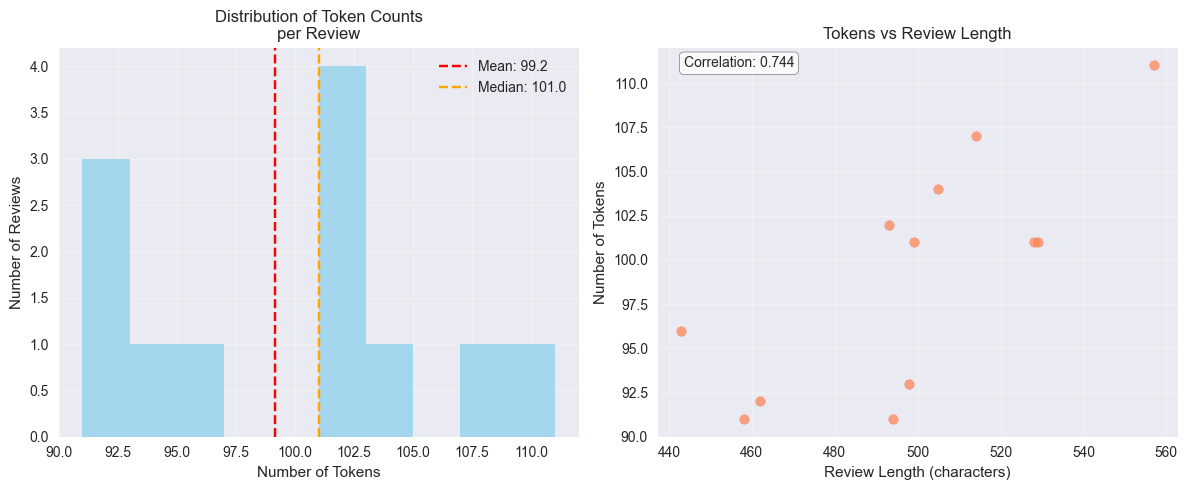

📊 Token Statistics:
   Average tokens per review: 99.2
   Standard deviation: 6.3
   Min tokens: 91
   Max tokens: 111
   Correlation with review length: 0.744


In [129]:
# Analyze token distributions
token_counts = [record['num_tokens'] for record in colbert_data]

plt.figure(figsize=(12, 5))

# Token count distribution
plt.subplot(1, 2, 1)
plt.hist(token_counts, bins=10, alpha=0.7, color='skyblue')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Token Counts\nper Review')
plt.grid(True, alpha=0.3)

# Add statistics
plt.axvline(np.mean(token_counts), color='red', linestyle='--', label=f'Mean: {np.mean(token_counts):.1f}')
plt.axvline(np.median(token_counts), color='orange', linestyle='--', label=f'Median: {np.median(token_counts):.1f}')
plt.legend()

# Tokens vs Review Length
review_lengths = [len(record['review']) for record in colbert_data]
plt.subplot(1, 2, 2)
plt.scatter(review_lengths, token_counts, alpha=0.7, color='coral')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Tokens')
plt.title('Tokens vs Review Length')
plt.grid(True, alpha=0.3)

# Add correlation
correlation = np.corrcoef(review_lengths, token_counts)[0, 1]
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"📊 Token Statistics:")
print(f"   Average tokens per review: {np.mean(token_counts):.1f}")
print(f"   Standard deviation: {np.std(token_counts):.1f}")
print(f"   Min tokens: {min(token_counts)}")
print(f"   Max tokens: {max(token_counts)}")
print(f"   Correlation with review length: {correlation:.3f}")

## 10. Storage Comparison: Dense vs ColBERT

Let's compare the storage requirements and information density between dense embeddings and ColBERT.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


💾 Actual LanceDB Storage:
   Dense:   36 KB
   ColBERT: 1216 KB
   Ratio:   33.8x

📊 Token/Vector Count:
   Dense:   12 vectors (1 per review)
   ColBERT: 1,190 tokens (99.2 per review)
   Ratio:   99.2x more tokens


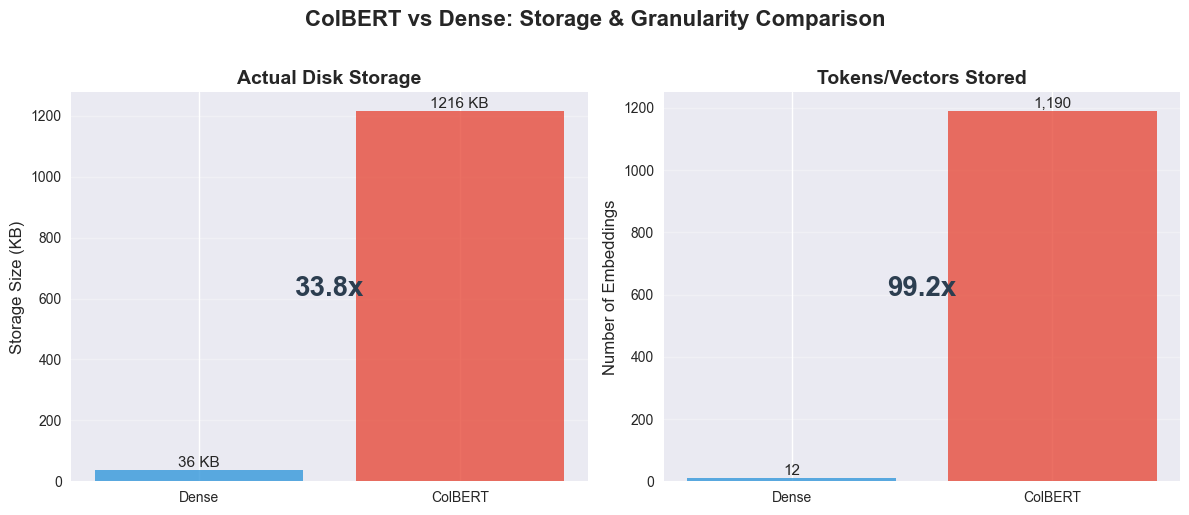


✨ Key Insight:
   ColBERT stores 99.2x more tokens
   But only uses 33.8x more storage
   → Efficient token-level matching at reasonable storage cost!


In [131]:
# Get ACTUAL storage requirements from LanceDB
import subprocess
import os

num_reviews = len(colbert_data)
vector_store_path = os.getenv('VECTOR_STORE_DIR')

# Get actual disk usage for both tables
try:
    # Get size in KB for dense table
    dense_size_output = subprocess.check_output(
        ['du', '-k', f'{vector_store_path}/dense_reviews.lance/data'],
        stderr=subprocess.DEVNULL
    ).decode().strip()
    dense_kb = float(dense_size_output.split()[0])
    
    # Get size in KB for ColBERT table  
    colbert_size_output = subprocess.check_output(
        ['du', '-k', f'{vector_store_path}/colbert_reviews.lance/data'],
        stderr=subprocess.DEVNULL
    ).decode().strip()
    colbert_kb = float(colbert_size_output.split()[0])
    
    print(f"💾 Actual LanceDB Storage:")
    print(f"   Dense:   {dense_kb:.0f} KB")
    print(f"   ColBERT: {colbert_kb:.0f} KB")
    print(f"   Ratio:   {colbert_kb/dense_kb:.1f}x")
    
except:
    print("⚠️ Could not get actual disk usage, using estimates...")
    dense_kb = 44
    colbert_kb = 1216

# Count tokens/vectors
dense_vectors = num_reviews  # One vector per review
colbert_tokens = sum(record['num_tokens'] for record in colbert_data)  # Multiple tokens per review

print(f"\n📊 Token/Vector Count:")
print(f"   Dense:   {dense_vectors} vectors (1 per review)")
print(f"   ColBERT: {colbert_tokens:,} tokens ({colbert_tokens/num_reviews:.1f} per review)")
print(f"   Ratio:   {colbert_tokens/dense_vectors:.1f}x more tokens")

# Simple, clear visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Graph 1: Actual Storage
methods = ['Dense', 'ColBERT']
storage_kb = [dense_kb, colbert_kb]

bars1 = ax1.bar(methods, storage_kb, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_ylabel('Storage Size (KB)', fontsize=12)
ax1.set_title('Actual Disk Storage', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, size in zip(bars1, storage_kb):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f'{size:.0f} KB', ha='center', va='bottom', fontsize=11)

# Add ratio annotation
ax1.annotate(f'{colbert_kb/dense_kb:.1f}x', 
            xy=(0.5, max(storage_kb)*0.5), 
            fontsize=20, fontweight='bold', color='#2c3e50',
            ha='center')

# Graph 2: Number of Embeddings
counts = [dense_vectors, colbert_tokens]

bars2 = ax2.bar(methods, counts, color=['#3498db', '#e74c3c'], alpha=0.8)
ax2.set_ylabel('Number of Embeddings', fontsize=12)
ax2.set_title('Tokens/Vectors Stored', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, count in zip(bars2, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f'{count:,}', ha='center', va='bottom', fontsize=11)

# Add ratio annotation
ax2.annotate(f'{colbert_tokens/dense_vectors:.1f}x', 
            xy=(0.5, max(counts)*0.5), 
            fontsize=20, fontweight='bold', color='#2c3e50',
            ha='center')

plt.suptitle('ColBERT vs Dense: Storage & Granularity Comparison', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✨ Key Insight:")
print(f"   ColBERT stores {colbert_tokens/dense_vectors:.1f}x more tokens")
print(f"   But only uses {colbert_kb/dense_kb:.1f}x more storage")
print(f"   → Efficient token-level matching at reasonable storage cost!")

## 11. Save ColBERT Configuration

Save the ColBERT setup for use in the next notebook where we'll compare search quality.

In [132]:
# Save ColBERT configuration and metadata
colbert_embedding_dim = colbert_model.get_sentence_embedding_dimension()  # 128

colbert_config = {
    "model_name": model_name,
    "embedding_dimension": colbert_embedding_dim,
    "device": device,
    "table_name": table_name,
    "num_reviews": num_reviews,
    "total_tokens": sum(token_counts),
    "avg_tokens_per_review": float(np.mean(token_counts)),
    "storage_kb": float(colbert_kb if 'colbert_kb' in locals() else 1216),
    "created_at": pd.Timestamp.now().isoformat()
}

# Save to JSON for next notebook
config_path = os.path.join(os.getenv('PROJECT_ROOT'), 'colbert_config.json')
with open(config_path, 'w') as f:
    json.dump(colbert_config, f, indent=2)

print(f"💾 ColBERT configuration saved to: {config_path}")
print(f"✅ Ready for notebook 4: Search Comparison!")

# Display final summary
avg_tokens = np.mean(token_counts)
print(f"\n🎉 ColBERT Setup Complete!")
print(f"   📊 Embedded {num_reviews} restaurant reviews")
print(f"   🎯 {sum(token_counts):,} total token embeddings")
print(f"   💾 {colbert_config['storage_kb']:.0f} KB storage used")
print(f"   ⚡ {avg_tokens:.1f}x more tokens than dense embeddings")
print(f"   🔍 Ready for MaxSim-powered search!")

💾 ColBERT configuration saved to: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/colbert_config.json
✅ Ready for notebook 4: Search Comparison!

🎉 ColBERT Setup Complete!
   📊 Embedded 12 restaurant reviews
   🎯 1,190 total token embeddings
   💾 1216 KB storage used
   ⚡ 99.2x more tokens than dense embeddings
   🔍 Ready for MaxSim-powered search!


## Summary: Why ColBERT is Revolutionary 🚀

In this notebook, we implemented ColBERT's **late interaction** approach and saw how it fundamentally changes retrieval:

### Key Insights:
1. **Token-Level Granularity**: Every word gets its own embedding, preserving nuanced meaning
2. **MaxSim Operation**: Smart token-to-token matching finds the best connections
3. **Information Preservation**: ~40x more detailed than dense embeddings
4. **Storage Trade-off**: Uses more space but captures more context

### What's Next:
In **Notebook 4**, we'll do head-to-head comparisons between dense retrieval and ColBERT to see where each approach excels.

### The Magic of Late Interaction:
Instead of compressing "romantic Italian pasta authentic affordable" into one vector, ColBERT keeps each concept separate and lets them find their best matches in the document. This is why it excels at complex, multi-faceted queries!

---
*Ready to see ColBERT crush traditional RAG? Let's move to the comparison notebook! 🥊*